# Validate plasma-cell programs in the Alameda cohort

**Biology rationale.** External single-cell validation tests whether amyloidogenic-versus-polyclonal plasma-cell signatures generalize across cohorts.

**Aim.** Identify plasma cells and compare disease-associated programs in the Alameda dataset.

**Data input.** `./GSE175385_Seurat_object.rds`, `Alameda.h5ad`, `AL_sample_vs_HA_sample_pairwise_DE_full.csv`, `AL_sample_vs_HA_sample_pairwise_DE_significant.csv`



**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Packages and setup


In [2]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
set.seed(123)

In [3]:
# Set these *before* library(reticulate) or library(sceasy)
Sys.setenv(RETICULATE_PYTHON = "/home/miniconda3/envs/carlin/bin/python")
options(reticulate.conda_binary = "/home/miniconda3/bin/conda")

library(reticulate)
py_config()  # should now show your conda 'jupyter' Python


python:         /home/miniconda3/envs/carlin/bin/python
libpython:      /home/miniconda3/envs/carlin/lib/libpython3.8.so
pythonhome:     /home/miniconda3/envs/carlin:/home/miniconda3/envs/carlin
version:        3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35)  [GCC 12.3.0]
numpy:          /home/miniconda3/envs/carlin/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by RETICULATE_PYTHON

In [4]:
sce1_plasma<-readRDS(file='./GSE175385_Seurat_object.rds')

scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



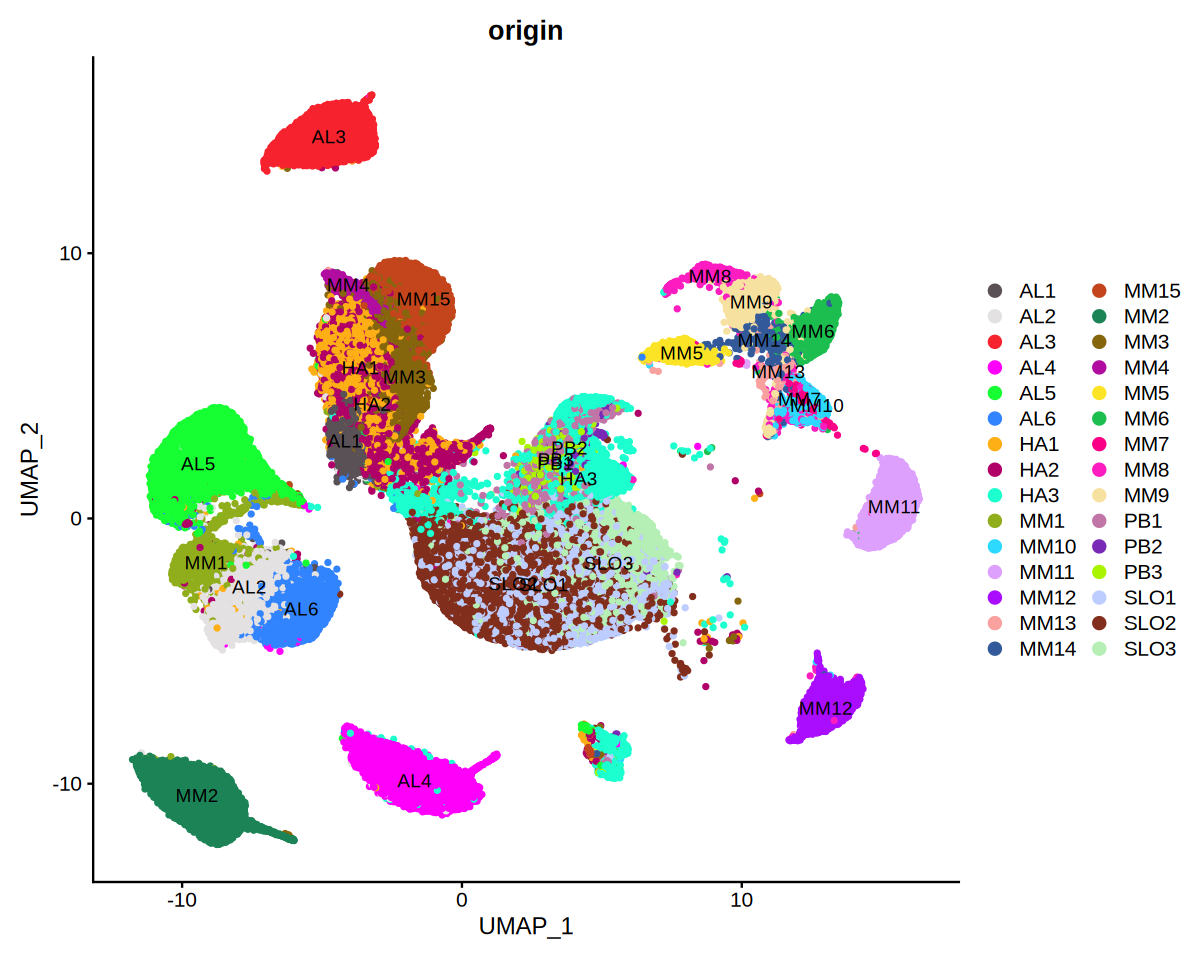

In [5]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "umap", group.by = c("origin"),label=T) 

In [6]:
sce1_plasma

An object of class Seurat 
48672 features across 142778 samples within 2 assays 
Active assay: SCT (22329 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

## 2. Normalization, integration, and dimensional reduction



  AL1   AL2   AL3   AL4   AL5   AL6   HA1   HA2   HA3   MM1  MM10  MM11  MM12 
 2136  5011  7392  9021 11978  6591  5017  5067  6203  3293   972  5186  3196 
 MM13  MM14  MM15   MM2   MM3   MM4   MM5   MM6   MM7   MM8   MM9   PB1   PB2 
  419   603  6121 10529  4976   986  1814  2784   342   874  3385  1892   657 
  PB3  SLO1  SLO2  SLO3 
 1717 10420 17802  6394 


  AL1   AL2   AL3   AL4   AL5   AL6   HA1   HA2   HA3 
 2136  5011  7392  9021 11978  6591  5017  5067  6203 

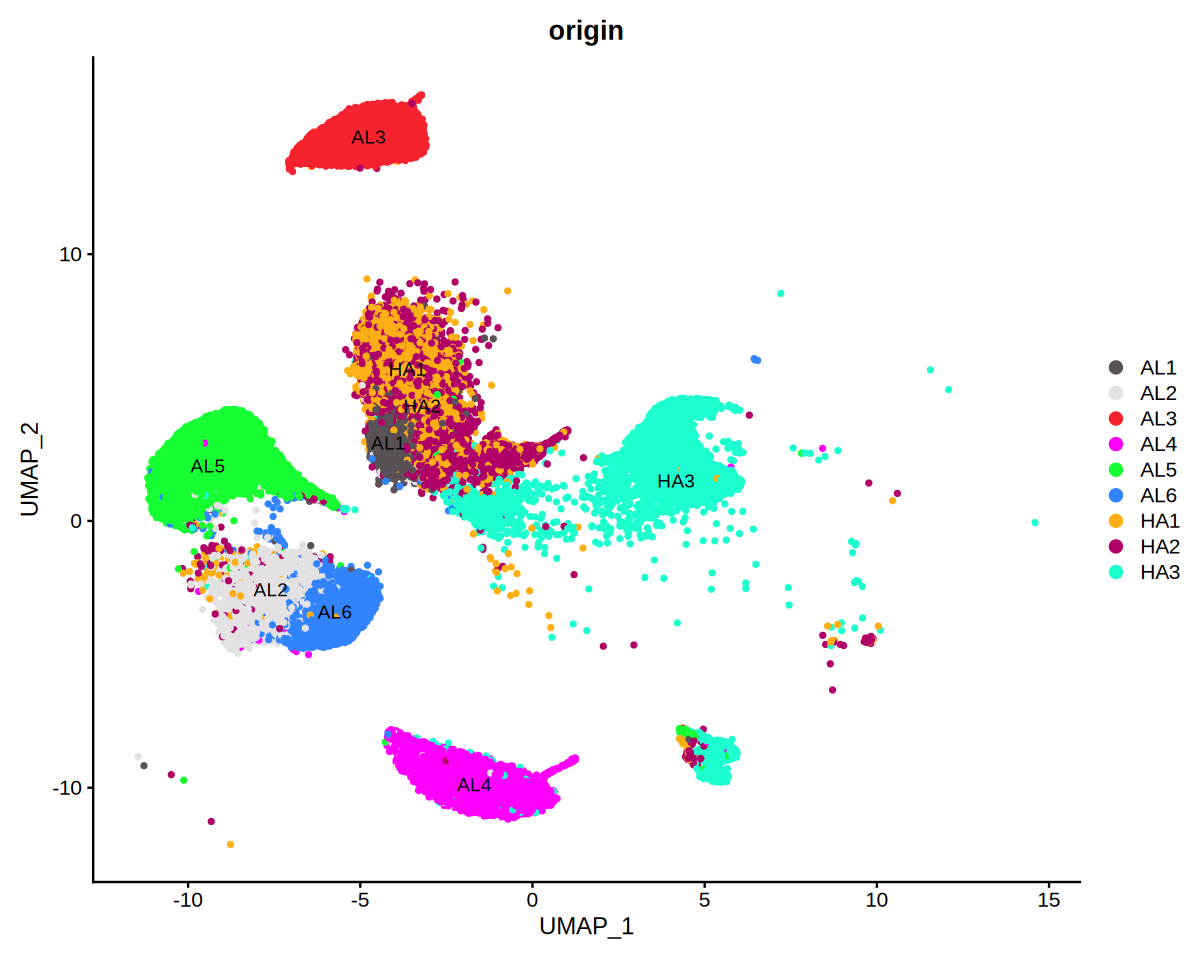

In [7]:
library(Seurat)
library(scCustomize)

# Check origin values
table(sce1_plasma$origin)

# Select cells whose origin starts with AL or HA
cells_AL_HA <- colnames(sce1_plasma)[
  grepl("^(AL|HA)", sce1_plasma$origin)
]

# Subset object
sce1_plasma_AL_HA <- subset(
  sce1_plasma,
  cells = cells_AL_HA
)

# Confirm
table(sce1_plasma_AL_HA$origin)

# Plot
options(repr.plot.height = 8, repr.plot.width = 10)

DimPlot_scCustom(
  sce1_plasma_AL_HA,
  pt.size = 1,
  reduction = "umap",
  group.by = "origin",
  label = TRUE
)

In [8]:
sce1_plasma<-sce1_plasma_AL_HA

In [9]:
# run standard anlaysis workflow
sce1_plasma <- NormalizeData(sce1_plasma)
sce1_plasma <- FindVariableFeatures(sce1_plasma)

## 3. Step 1: Identify genes starting with "IG"


In [10]:
# Step 1: Identify genes starting with "IG"
ig_genes <- grep("^IGK|^IGH|^IGL", rownames(sce1_plasma), value = TRUE)

# Step 2: Exclude these genes from variable features
current_variable_features <- VariableFeatures(sce1_plasma)
filtered_variable_features <- setdiff(current_variable_features, ig_genes)
VariableFeatures(sce1_plasma) <- filtered_variable_features

# Step 3: Proceed with PCA and UMAP
sce1_plasma <- ScaleData(sce1_plasma, features = VariableFeatures(sce1_plasma))
sce1_plasma <- RunPCA(sce1_plasma, features = VariableFeatures(sce1_plasma))

Centering and scaling data matrix

PC_ 1 
Positive:  CCND1, FRZB, MDK, QPCT, AREG, CD9, LINC01781, CADM1, DHRS9, HSPB1 
	   KCNS3, GADD45A, CYTOR, NEB, UGT3A2, COMMD3, DKK1, HBD, FAM30A, DNAAF1 
	   LAMP5, CTSW, PIM2, DPEP1, TBCEL, DPEP3, CTHRC1, IFI27, EDNRB, LSR 
Negative:  AIF1, TYROBP, PTPRC, HLA-DRA, COTL1, FCER1G, HLA-DRB1, LST1, HLA-DPB1, LCP1 
	   MS4A7, FYB1, ZEB2, ITGB2, TNFRSF1B, FGL2, HLA-DPA1, CEBPD, SERPINA1, MPEG1 
	   RIPOR2, FCN1, C5AR1, IGSF6, FCGR3A, C1orf162, GNAI2, LYN, NCF2, MNDA 
PC_ 2 
Positive:  ITGB7, CCND2, RBP1, PPP1R14A, RPS4Y1, LMNA, CST6, RNASET2, LY6E, CYBA 
	   SYNGR2, PEBP1, RNASE6, TCN2, S100A10, NTRK2, CLEC2B, ARID5A, TMSB10, EZR 
	   LGMN, FTH1, PODXL2, EMP3, ANXA1, ANG, EFNA1, CD74, LY86, SPINT2 
Negative:  BTG2, FOS, DUSP1, MT-ND3, MT-ATP6, CD48, FOSB, GLCCI1, CCND1, MT-CO1 
	   BHLHE41, CDV3, KLF2, CITED2, H1FX, CHCHD10, JUN, PABPC4, TXNDC5, DDX17 
	   OTUD1, MTRNR2L12, LINC01781, SEL1L3, SRSF7, PNRC1, PDK1, KMT2A, IER2, PRDM1 
PC_ 3 
Positive:  

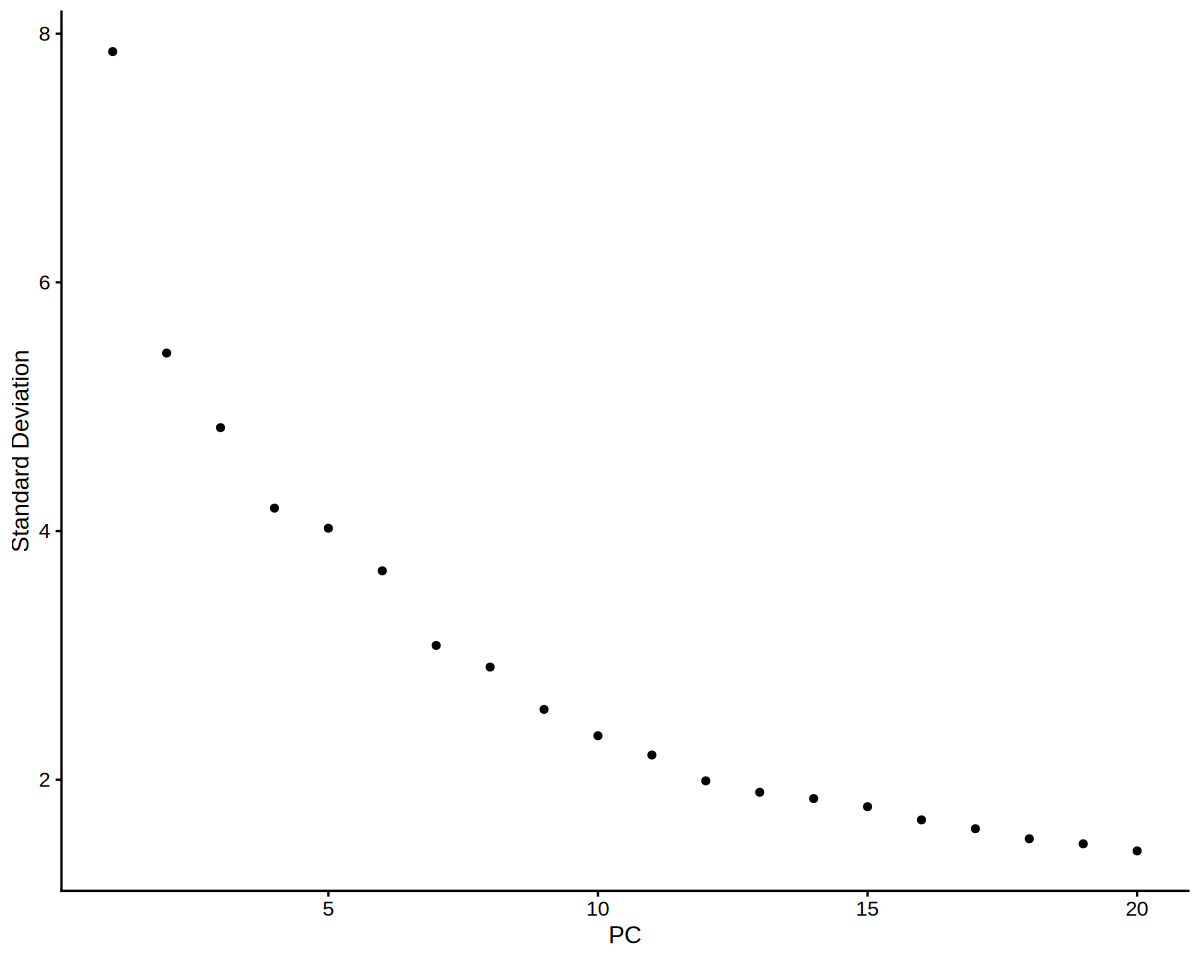

In [11]:
ElbowPlot(sce1_plasma)

In [12]:
sce1_plasma <- FindNeighbors(sce1_plasma, dims = 1:15, reduction = "pca")
sce1_plasma <- FindClusters(sce1_plasma, resolution = 1, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 58416
Number of edges: 1795300

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9017
Number of communities: 23
Elapsed time: 11 seconds


In [13]:
sce1_plasma <- RunUMAP(sce1_plasma, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
22:44:38 UMAP embedding parameters a = 0.9922 b = 1.112

22:44:38 Read 58416 rows and found 15 numeric columns

22:44:38 Using Annoy for neighbor search, n_neighbors = 30

22:44:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

22:44:42 Writing NN index file to temp file /tmp/RtmpcLxxKU/file15b5a415eb5483

22:44:42 Searching Annoy index using 1 thread, search_k = 3000

22:45:00 Annoy recall = 100%

22:45:01 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

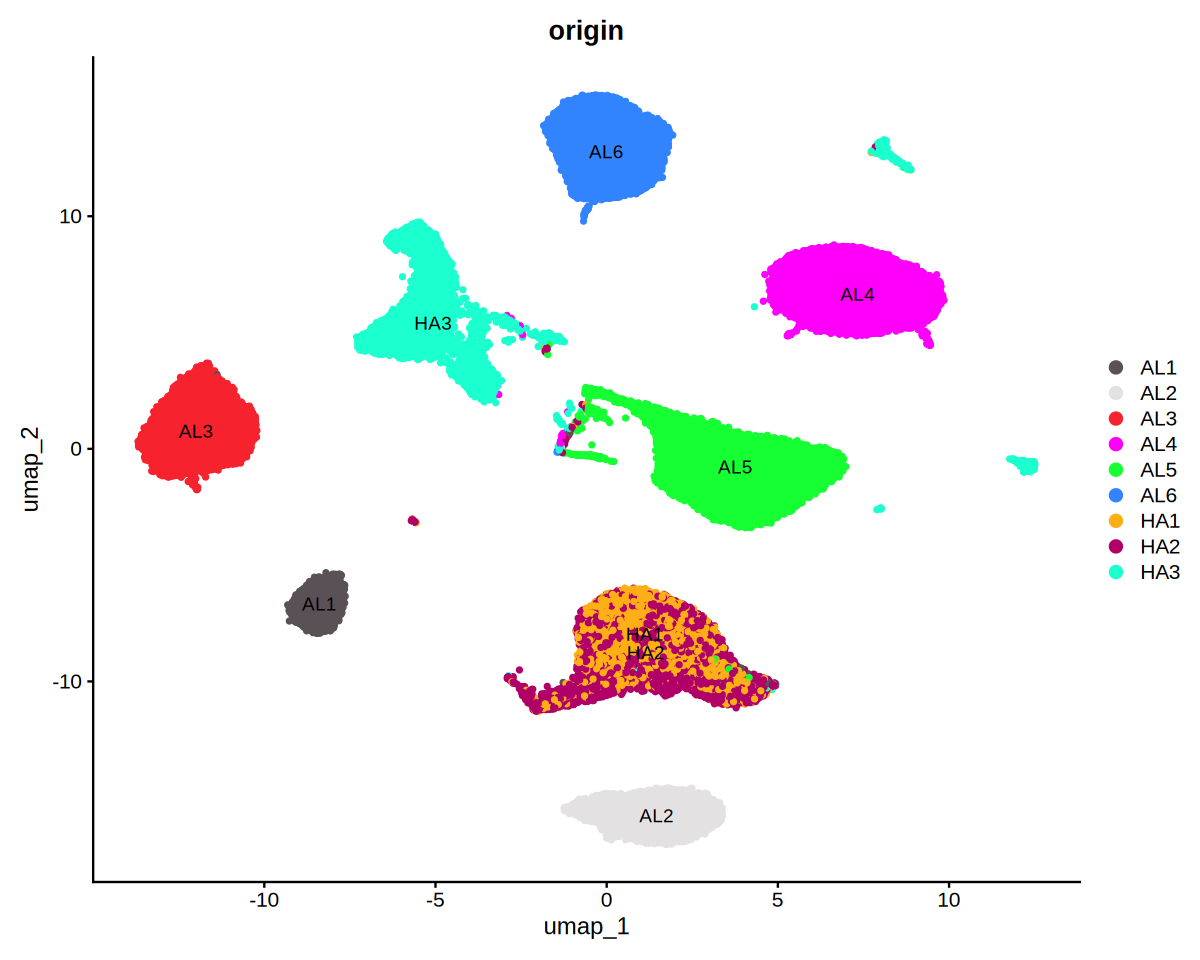

In [14]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("origin"),label=T) 

## 4. Visualization and figure generation


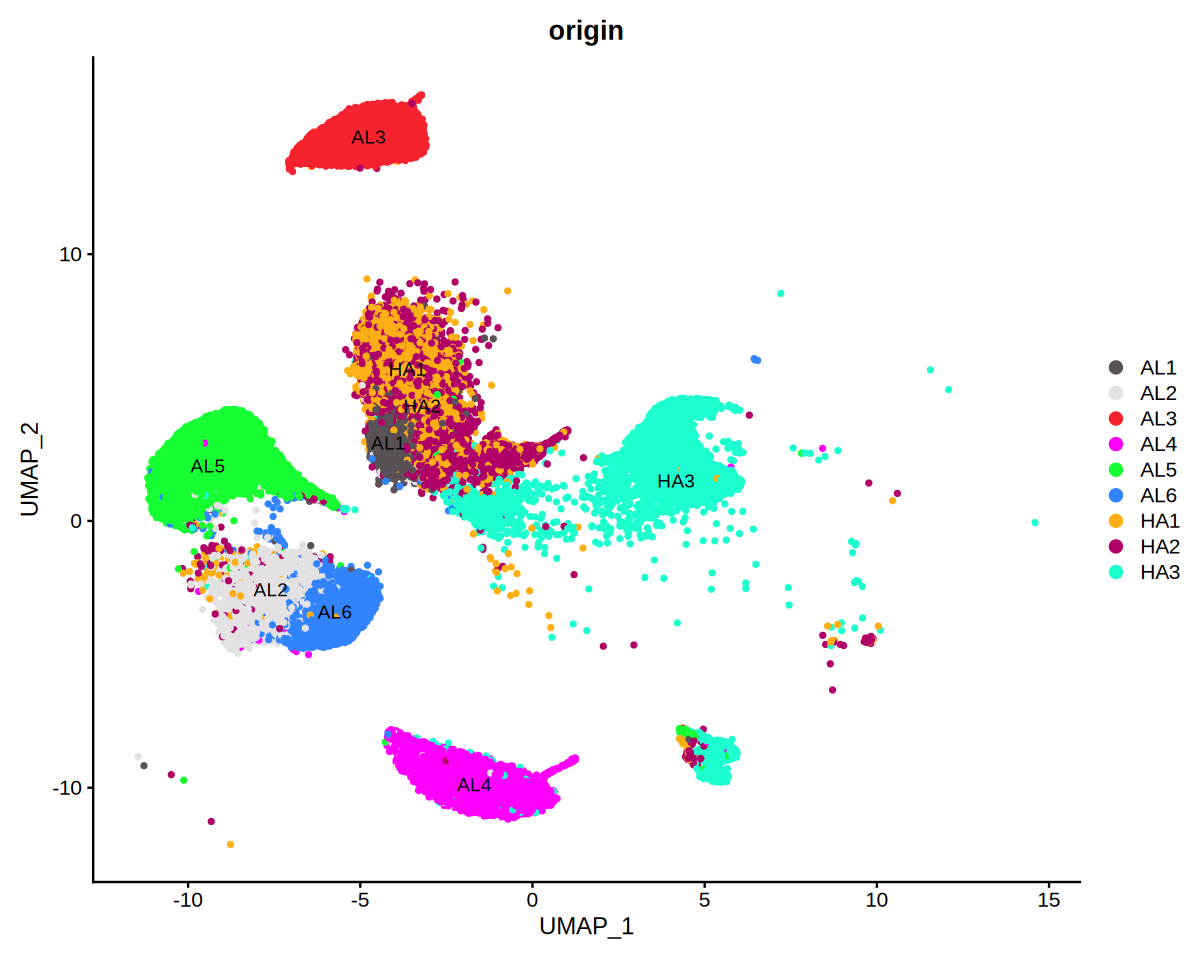

In [15]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "umap", group.by = c("origin"),label=T) 

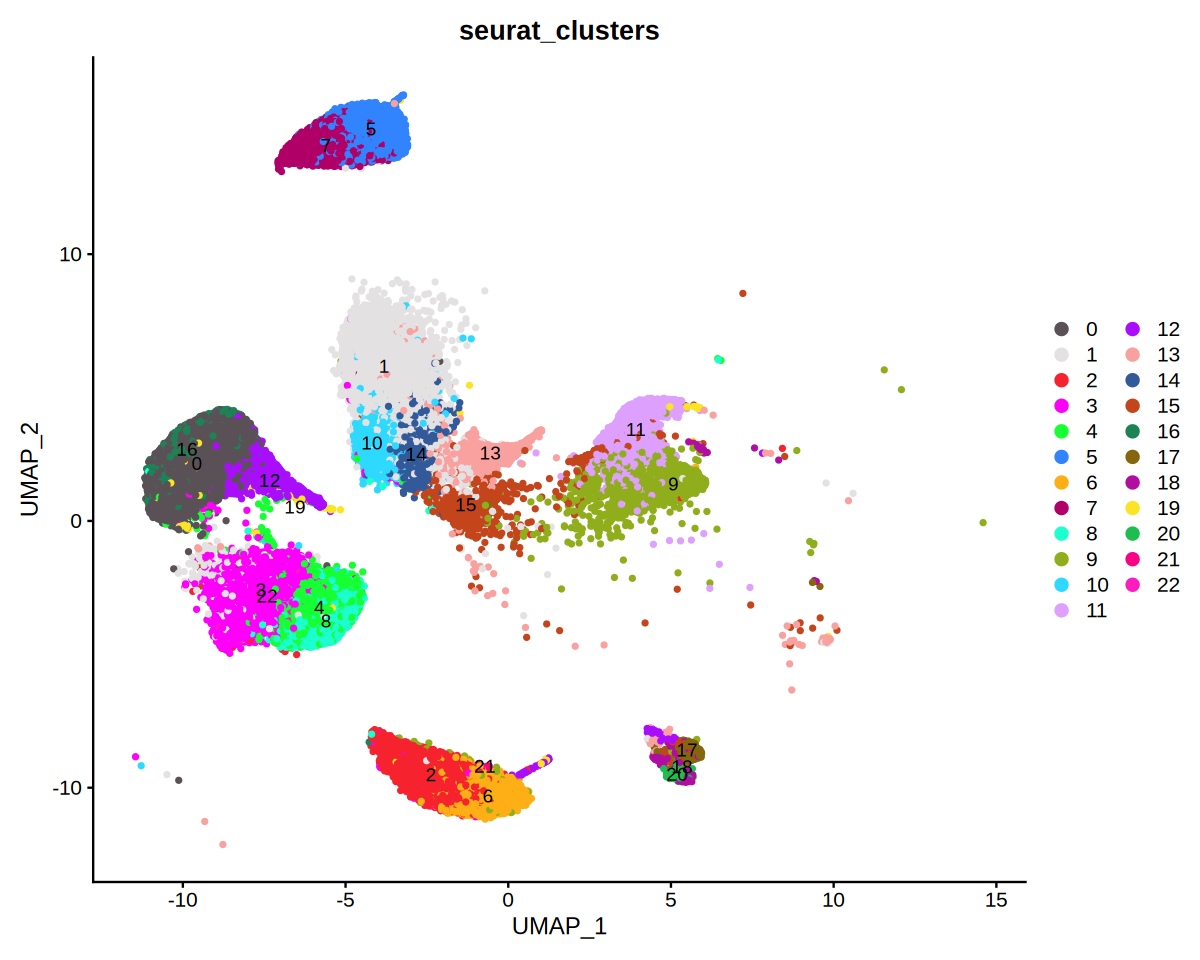

In [17]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "umap", group.by = c("seurat_clusters"),label=T) 


NOTE: DimPlot_scCustom returns split plots as layout of all plots each
with their own axes as opposed to Seurat which returns with shared x or y axis.
To return to Seurat behvaior set `split_seurat = TRUE`.

-----This message will be shown once per session.-----


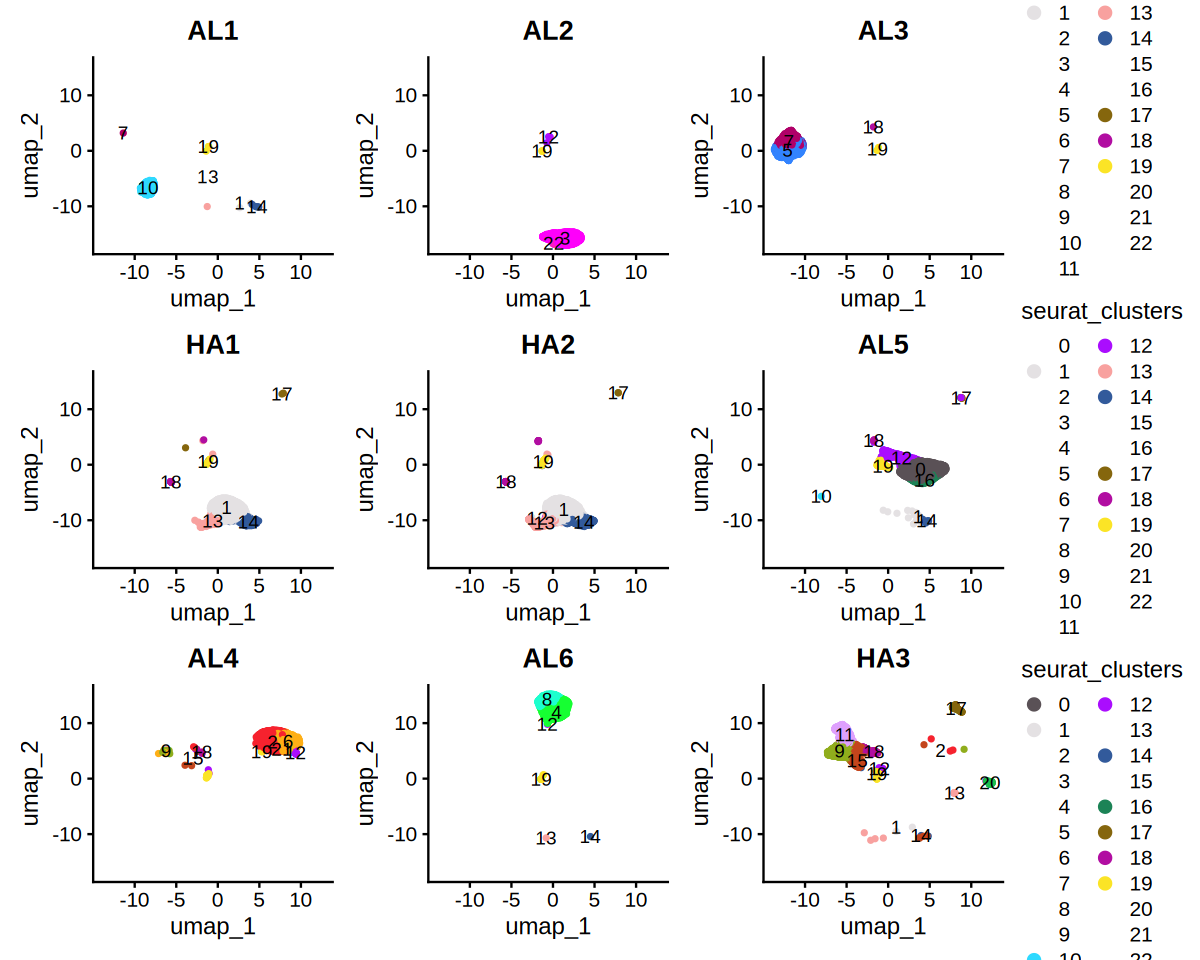

In [18]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", split.by = c("origin"),group.by = c("seurat_clusters"),label=T) 

## 5. Packages and setup


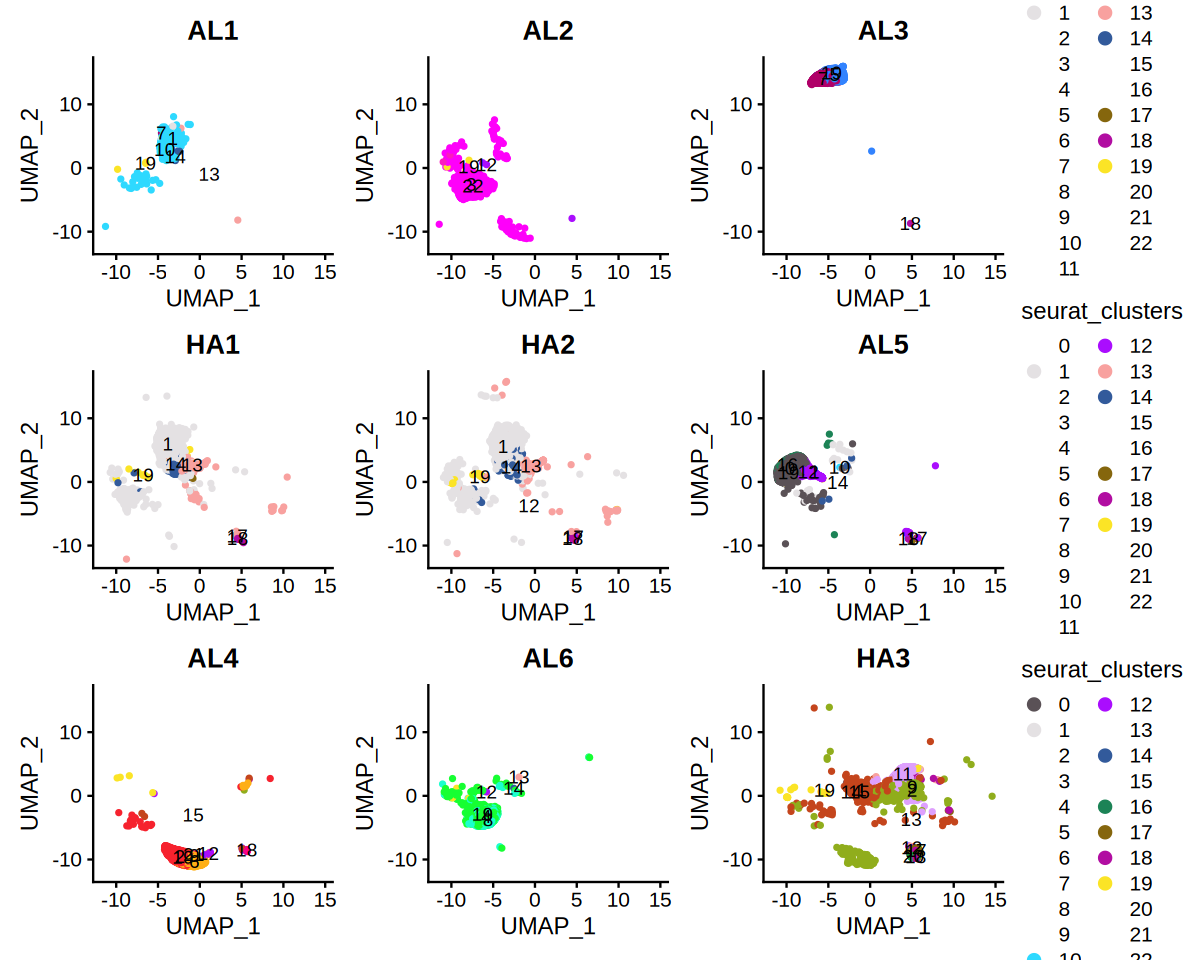

In [19]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "umap", split.by = c("origin"),group.by = c("seurat_clusters"),label=T) 

In [16]:
library(Seurat)
library(sceasy)

# Subset both groups together in one step
subset_cells <- sce1_plasma

# Ensure RNA assay is properly formatted
subset_cells[["RNA"]] <- as(subset_cells[["RNA"]], "Assay")

# Save as .h5ad
sceasy::convertFormat(subset_cells, from = "seurat", to = "anndata", outFile = "Alameda.h5ad")


AnnData object with n_obs × n_vars = 58416 × 26343
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'TP11', 'TP21', 'TP31', 'TP41', 'TP51', 'TP61', 'TP71', 'TP81', 'TP91', 'TP101', 'TP111', 'TP121', 'TP131', 'TP_Max', 'TP_Max_T', 'S.Score', 'G2M.Score', 'Phase', 'old.ident'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [20]:
library(Seurat)
library(dplyr)
library(tibble)
library(stringr)
library(purrr)

# ============================================================
# 0) Settings
# ============================================================

seurat_obj <- sce1_plasma   # change this to your object

sample_col <- "origin"

stopifnot(sample_col %in% colnames(seurat_obj@meta.data))

# Optional: choose assay
# DefaultAssay(seurat_obj) <- "RNA"

# If using Seurat v5 and RNA has multiple layers, this may help:
# seurat_obj <- JoinLayers(seurat_obj)

min_al_cells <- 10
min_ha_cells <- 10

logfc_use <- 0.25
min_pct_use <- 0.1
test_use <- "wilcox"


# ============================================================
# 1) Clean metadata column
# ============================================================

seurat_obj[[sample_col]] <- as.character(seurat_obj@meta.data[[sample_col]])

seurat_obj[[sample_col]][
  seurat_obj@meta.data[[sample_col]] %in% c("NA", "NaN", "", "nan")
] <- NA

# Keep cells with valid origin/sample annotation
keep <- !is.na(seurat_obj@meta.data[[sample_col]])

seurat_obj <- seurat_obj[, keep]

# Confirm sample sizes
sample_size_table <- table(seurat_obj@meta.data[[sample_col]], useNA = "ifany")
print(sample_size_table)


# ============================================================
# 2) Define AL and HA samples
# ============================================================

all_samples <- unique(seurat_obj@meta.data[[sample_col]])

al_samples <- all_samples[str_detect(all_samples, "^AL")]
ha_samples <- all_samples[str_detect(all_samples, "^HA")]

message("Number of AL samples: ", length(al_samples))
message("Number of HA samples: ", length(ha_samples))

print(al_samples)
print(ha_samples)

if (length(al_samples) == 0) {
  stop("No AL samples detected from origin using pattern '^AL'.")
}

if (length(ha_samples) == 0) {
  stop("No HA samples detected from origin using pattern '^HA'.")
}


# ============================================================
# 3) Containers for results
# ============================================================

pairwise_results <- list()


# ============================================================
# 4) Pairwise DE:
#    each AL sample vs each HA sample
# ============================================================

for (al in al_samples) {
  
  message("Processing AL sample: ", al)
  
  al_cells <- colnames(seurat_obj)[
    seurat_obj@meta.data[[sample_col]] == al
  ]
  
  n_al <- length(al_cells)
  
  for (ha in ha_samples) {
    
    message("  Comparing ", al, " vs ", ha)
    
    ha_cells <- colnames(seurat_obj)[
      seurat_obj@meta.data[[sample_col]] == ha
    ]
    
    n_ha <- length(ha_cells)
    
    if (n_al < min_al_cells || n_ha < min_ha_cells) {
      message(
        "    Skipping ", al, " vs ", ha,
        ": AL cells = ", n_al,
        ", HA cells = ", n_ha
      )
      next
    }
    
    de_obj <- seurat_obj[, c(al_cells, ha_cells)]
    
    de_obj$DE_group <- ifelse(
      colnames(de_obj) %in% al_cells,
      "AL",
      "HA"
    )
    
    Idents(de_obj) <- factor(
      de_obj$DE_group,
      levels = c("AL", "HA")
    )
    
    markers_pairwise <- tryCatch({
      FindMarkers(
        de_obj,
        ident.1 = "AL",
        ident.2 = "HA",
        logfc.threshold = logfc_use,
        min.pct = min_pct_use,
        test.use = test_use
      )
    }, error = function(e) {
      message("    DE failed for ", al, " vs ", ha, ": ", e$message)
      return(NULL)
    })
    
    if (!is.null(markers_pairwise) && nrow(markers_pairwise) > 0) {
      
      markers_pairwise <- markers_pairwise %>%
        rownames_to_column("gene") %>%
        mutate(
          comparison = "AL_sample_vs_HA_sample",
          AL_sample = al,
          HA_sample = ha,
          n_AL_cells = n_al,
          n_HA_cells = n_ha
        ) %>%
        arrange(p_val_adj)
      
      pairwise_results[[paste(al, ha, sep = "__vs__")]] <- markers_pairwise
    }
  }
}


# ============================================================
# 5) Combine and save full DE table
# ============================================================

pairwise_table <- bind_rows(pairwise_results)

# View
head(pairwise_table)

write.csv(
  pairwise_table,
  file = "AL_sample_vs_HA_sample_pairwise_DE_full.csv",
  row.names = FALSE
)


# ============================================================
# 6) Save significant-only table
# ============================================================

pairwise_sig <- pairwise_table %>%
  filter(p_val_adj < 0.05)

write.csv(
  pairwise_sig,
  file = "AL_sample_vs_HA_sample_pairwise_DE_significant.csv",
  row.names = FALSE
)


# ============================================================
# 7) Quick summary
# ============================================================

pairwise_sig %>%
  count(AL_sample, HA_sample, name = "n_significant_genes") %>%
  arrange(AL_sample, desc(n_significant_genes))


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:


  AL1   AL2   AL3   AL4   AL5   AL6   HA1   HA2   HA3 
 2136  5011  7392  9021 11978  6591  5017  5067  6203 


Number of AL samples: 6

Number of HA samples: 3



[1] "AL1" "AL2" "AL3" "AL5" "AL4" "AL6"
[1] "HA1" "HA2" "HA3"


Processing AL sample: AL1

  Comparing AL1 vs HA1

  Comparing AL1 vs HA2

  Comparing AL1 vs HA3

Processing AL sample: AL2

  Comparing AL2 vs HA1

  Comparing AL2 vs HA2

  Comparing AL2 vs HA3

Processing AL sample: AL3

  Comparing AL3 vs HA1

  Comparing AL3 vs HA2

  Comparing AL3 vs HA3

Processing AL sample: AL5

  Comparing AL5 vs HA1

  Comparing AL5 vs HA2

  Comparing AL5 vs HA3

Processing AL sample: AL4

  Comparing AL4 vs HA1

  Comparing AL4 vs HA2

  Comparing AL4 vs HA3

Processing AL sample: AL6

  Comparing AL6 vs HA1

  Comparing AL6 vs HA2

  Comparing AL6 vs HA3



,gene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,comparison,AL_sample,HA_sample,n_AL_cells,n_HA_cells
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>
1,IGLV2-8,0,6.349385,0.997,0.030,0,AL_sample_vs_HA_sample,AL1,HA1,2136,5017
2,CCND1,0,9.001645,0.922,0.006,0,AL_sample_vs_HA_sample,AL1,HA1,2136,5017
3,IGHM,0,-5.351884,0.102,0.989,0,AL_sample_vs_HA_sample,AL1,HA1,2136,5017
4,LINC01781,0,4.448799,0.850,0.045,0,AL_sample_vs_HA_sample,AL1,HA1,2136,5017
5,EAF2,0,-5.280559,0.098,0.898,0,AL_sample_vs_HA_sample,AL1,HA1,2136,5017
6,RPS4Y1,0,9.599274,0.760,0.001,0,AL_sample_vs_HA_sample,AL1,HA1,2136,5017


AL_sample,HA_sample,n_significant_genes
<chr>,<chr>,<int>
AL1,HA3,5248
AL1,HA2,3023
AL1,HA1,2721
AL2,HA3,5121
AL2,HA2,2665
AL2,HA1,2378
AL3,HA3,4943
AL3,HA2,3139
AL3,HA1,2885
